In [1]:
import os
import sys, pathlib
import numpy as np

sys.path.append(os.path.join(os.path.expanduser('~'), 'Programming', 'In_Vivo','physion', 'src'))

from physion.utils import plot_tools as pt
from physion.analysis.read_NWB import Data, scan_folder_for_NWBfiles
from physion.dataviz.imaging import show_CaImaging_FOV
from physion.dataviz.raw import plot as plot_raw, find_default_plot_settings
#from physion.dataviz.raw import plot_test
from physion.dataviz import tools as dv_tools

import matplotlib.pyplot as plt

from scipy import stats
from physion.analysis.process_NWB import EpisodeData

base_path = os.path.join(os.path.expanduser('~'), 'Desktop', 'NWBs')

from physion.dataviz.episodes.trial_average import plot as plot_trial_average

import random

In [2]:
filename = os.path.join(os.path.expanduser('~'), 'DATA','In_Vivo_experiments', 'NDNF-WT-Dec-2022','NWBs',  '2022_12_14-13-27-41.nwb')
data = Data(filename, verbose=False)

data.build_dFoF()
data.build_running_speed()


calculating dF/F with method "percentile" [...]

  ** all ROIs passed the positive F0 criterion ** 

-> dFoF calculus done !  (calculation took 0.0s)


In [3]:
data.nwbfile.acquisition

{'CaImaging-TimeSeries': CaImaging-TimeSeries pynwb.ophys.TwoPhotonSeries at 0x2835171537600
 Fields:
   comments: raw-data-folder=**mnt**c**Users**laura.gonzalez**DATA**In_Vivo_experiments**NDNF-WT-Dec-2022****Processed**2022_12_14**13-27-41**TSeries-12142022-001
   conversion: 1.0
   data: <HDF5 dataset "data": shape (2, 2, 2), type "<f8">
   description: no description
   dimension: <HDF5 dataset "dimension": shape (1,), type "<i8">
   imaging_plane: my_imgpln pynwb.ophys.ImagingPlane at 0x2834851887440
 Fields:
   conversion: 1.0
   description: Depth=-97.5[um]
   device: Imaging device with settings: 
  {'activeMode': 'ResonantGalvo', 'bitDepth': '13', 'currentScanAmplitude': {'XAxis': '-3.47', 'YAxis': '8.65'}, 'currentScanCenter': {'XAxis': '0.045', 'YAxis': '0.047'}, 'dwellTime': '0.4', 'framePeriod': '0.033987239', 'interlacedScanChannelMapping': {'0': '0', '1': '1'}, 'interlacedScanTrackCount': '2', 'interlacedScanTrackLasers': {'0': '0', '1': '1', '2': '', '3': ''}, 'interla

In [4]:
ep = EpisodeData(data,
                 prestim_duration=0,
                 protocol_id=0,
                 quantities=['dFoF', 'running_speed'])

  Number of episodes over the whole recording: 40/251 (with protocol condition)
  building episodes with 2 modalities [...]
  -> [ok] episodes ready !


(40, 53, 4998)
11
(40, 4998)


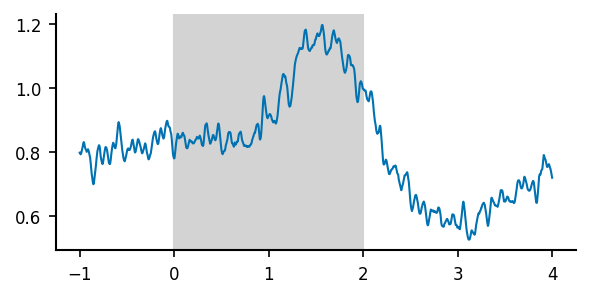

In [5]:
print(ep.dFoF.shape) # (episodes, rois, time samples)
n_episodes = ep.dFoF.shape[0]
#roi = random.randint(0, ep.dFoF.shape[1]-1)  #chosen randomly
roi=11
print(roi)

fig, ax = pt.figure(figsize=(2, 2.5))
temp = ep.dFoF[:,roi,:]
print(temp.shape)
ax.plot(ep.t, temp.mean(axis=0)) #mean of all the episodes
ax.axvspan(0, 2, color='lightgrey')

In [6]:
#ep.state is True if animal is running and False if resting
print(np.mean(ep.running_speed, axis=1))
ep.state = [True if speed > 0.07 else False for speed in np.mean(ep.running_speed, axis=1)]
print(ep.state)


[0.03631019 0.00447204 0.00357763 0.01991135 0.03030798 0.02954046
 0.02849531 0.00882921 0.01520493 0.01430989 0.01591152 0.01337173
 0.008216   0.0435193  0.02146308 0.01349136 0.0169404  0.00447204
 0.05373151 0.00894408 0.00948671 0.00894408 0.00548579 0.00404505
 0.01982494 0.03628241 0.03841371 0.05035746 0.01160235 0.06728404
 0.04574362 0.03723124 0.06979487 0.07394347 0.09007936 0.00534172
 0.07791874 0.02805626 0.06886808 0.01889   ]
[False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, True, False, True, False, False, False]


4998


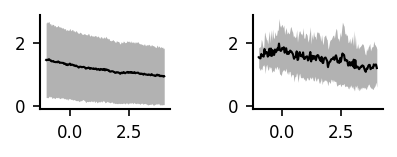

In [13]:
fig, AX = pt.figure(axes=(2,1))
roi= random.randint(0, ep.dFoF.shape[1]-1)  #chosen randomly

for state, ax in zip(np.unique(ep.state), AX):
    pt.plot(ep.t, 
            ep.dFoF[ep.state==state, roi, :].mean(axis=0), 
            sy=ep.dFoF[ep.state==state, roi, :].std(axis=0), 
            ax=ax, title=state)

pt.set_common_ylims(AX)

print(len(ep.dFoF[ep.state==state, roi, :].mean(axis=0)))

In [ ]:
i= 0
for run_speed in ep.running_speed :
    print(ep.state)
    if np.mean(run_speed, axis=0) > 0.5:
        ep.state[i] = True
    else: 
        ep.state[i] = False
    i+=1

(40, 8998)
(40, 8998)


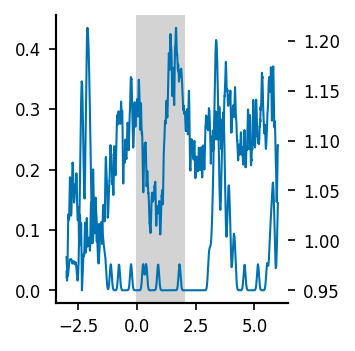

In [39]:
roi=random.randint(0, ep.dFoF.shape[1]-1)

fig, ax1 = plt.subplots(figsize=(2, 2.5))
ax2 = ax1.twinx()
print(ep.running_speed.shape)
temp_dFoF = ep.dFoF[:,roi,:]
temp_running = ep.running_speed[roi,:]
print(temp_dFoF.shape)

ax1.plot(ep.t, temp_running)
ax2.plot(ep.t, temp_dFoF.mean(axis=0)) #mean of all the episodes
ax1.axvspan(0, 2, color='lightgrey')




In [ ]:
ep.angl